In [ ]:
# Di chuyển về thư mục mặc định của Kaggle
%cd /kaggle/working/

# Clone repository SAM2-UNet
!git clone https://github.com/WZH0120/SAM2-UNet.git

# Cài đặt các thư viện
%cd SAM2-UNet
!pip install -r requirements.txt

/kaggle/working
Cloning into 'SAM2-UNet'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 316 (delta 85), reused 58 (delta 58), pack-reused 208 (from 2)
Receiving objects: 100% (316/316), 3.26 MiB | 12.73 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/kaggle/working/SAM2-UNet
Looking in links: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%cd /kaggle/working/SAM2-UNet

!mkdir -p pretrained_weights
!wget -O pretrained_weights/sam2_hiera_small.pt https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt

/kaggle/working/SAM2-UNet
--2026-05-23 13:34:34--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.84.118.60, 99.84.118.117, 99.84.118.67, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.84.118.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184309650 (176M) [application/vnd.snesdev-page-table]
Saving to: ‘pretrained_weights/sam2_hiera_small.pt’

pretrained_weights/ 100%[===================>] 175.77M  44.9MB/s    in 3.8s    

2026-05-23 13:34:38 (45.8 MB/s) - ‘pretrained_weights/sam2_hiera_small.pt’ saved [184309650/184309650]



In [ ]:
import os
import glob

# Đường dẫn dataset của bạn
BASE_DIR = '/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019'
WORK_DIR = '/kaggle/working/dataset'

# Tạo thư mục đích
for split in ['train', 'val']:
    os.makedirs(f'{WORK_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{WORK_DIR}/{split}/masks', exist_ok=True)

def link_data(split_name, source_image_dir):
    image_paths = glob.glob(os.path.join(source_image_dir, '*.*'))
    count = 0
    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        base_name, _ = os.path.splitext(img_name)

        mask_path = os.path.join(BASE_DIR, 'GT', f'{base_name}.png')

        if os.path.exists(mask_path):
            dest_img = os.path.join(WORK_DIR, split_name, 'images', img_name)
            dest_mask = os.path.join(WORK_DIR, split_name, 'masks', f'{base_name}.png')

            if not os.path.exists(dest_img): os.symlink(img_path, dest_img)
            if not os.path.exists(dest_mask): os.symlink(mask_path, dest_mask)
            count += 1

    print(f"✅ Đã liên kết {count} cặp ảnh-mask cho tập {split_name}.")

print("Bắt đầu xử lý dữ liệu...")
link_data('train', os.path.join(BASE_DIR, 'Images', 'Train'))
link_data('val', os.path.join(BASE_DIR, 'Images', 'Test'))
print("Hoàn tất!")

Bắt đầu xử lý dữ liệu...
✅ Đã liên kết 1000 cặp ảnh-mask cho tập train.
✅ Đã liên kết 250 cặp ảnh-mask cho tập val.
Hoàn tất!


In [ ]:
import os

file_path = '/kaggle/working/SAM2-UNet/SAM2UNet.py'

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    if 'model_cfg = "sam2_hiera_l.yaml"' in content:
        content = content.replace('model_cfg = "sam2_hiera_l.yaml"', 'model_cfg = "sam2_hiera_s.yaml"')
        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(content)
        print("✅ Đã tự động vá lỗi cấu hình (chuyển sang bản Small) thành công!")
    elif 'model_cfg = "sam2_hiera_s.yaml"' in content:
        print("✅ File đã cấu hình bản Small sẵn, mọi thứ đã ổn định!")
    else:
        print("⚠️ Không tìm thấy dòng cấu hình để sửa.")
else:
    print("⚠️ Lỗi: Không tìm thấy file SAM2UNet.py, hãy kiểm tra lại Cell 1.")

✅ Đã tự động vá lỗi cấu hình (chuyển sang bản Small) thành công!


In [ ]:
import os

file_path = '/kaggle/working/SAM2-UNet/SAM2UNet.py'

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        code = f.read()

    # Sửa toàn bộ kênh đầu vào từ Large sang Small
    code = code.replace('144', '96')
    code = code.replace('288', '192')
    code = code.replace('576', '384')
    code = code.replace('1152', '768')

    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(code)

    print("✅ Đã vá lỗi cấu hình Channels sang bản Small thành công!")
else:
    print("⚠️ Lỗi: Không tìm thấy file SAM2UNet.py.")

✅ Đã vá lỗi cấu hình Channels sang bản Small thành công!


In [ ]:
%cd /kaggle/working/SAM2-UNet

!python train.py \
    --train_image_path /kaggle/working/dataset/train/images/ \
    --train_mask_path /kaggle/working/dataset/train/masks/ \
    --hiera_path pretrained_weights/sam2_hiera_small.pt \
    --save_path /kaggle/working/checkpoints/ \
    --epoch 100 \
    --lr 0.0001 \
    --batch_size 8

/kaggle/working/SAM2-UNet
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/kaggle/working/SAM2-UNet/sam2/modeling/sam/transformer.py:22: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please 

In [ ]:
%cd /kaggle/working/SAM2-UNet

!python test.py \
    --checkpoint /kaggle/working/checkpoints/SAM2-UNet-100.pth \
    --test_image_path /kaggle/working/dataset/val/images/ \
    --test_gt_path /kaggle/working/dataset/val/masks/ \
    --save_path /kaggle/working/results/

/kaggle/working/SAM2-UNet
/kaggle/working/SAM2-UNet/sam2/modeling/sam/transformer.py:22: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/kaggle/working/SAM2-UNet/test.py:38: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  res = F.upsample(res, size=gt.shape, mode='bilinear', align_corners=False)
Saving camourflage_00012.jpg
Saving camourflage_00018.jpg
Saving camourflage_00061.jpg
Saving camourflage_00064.jpg
Saving camourflage_00071.jpg
Saving camourflage_00079.jpg
Saving camourflage_00087.jpg
Saving camourflage_00088.jpg
Saving camourflage_00090.jpg
Saving camourflage_00097.jpg
Saving camourflage_00098.jpg
Saving camourflage_00100.jpg
Saving camourflage_00102.jpg
Saving camourflage_00112.jpg
Saving camourflage_00114.jpg
Saving camourflage_00120.jpg
Saving camourflage_00122.jpg
Saving camourflage_00124.jpg
Saving camourflage_

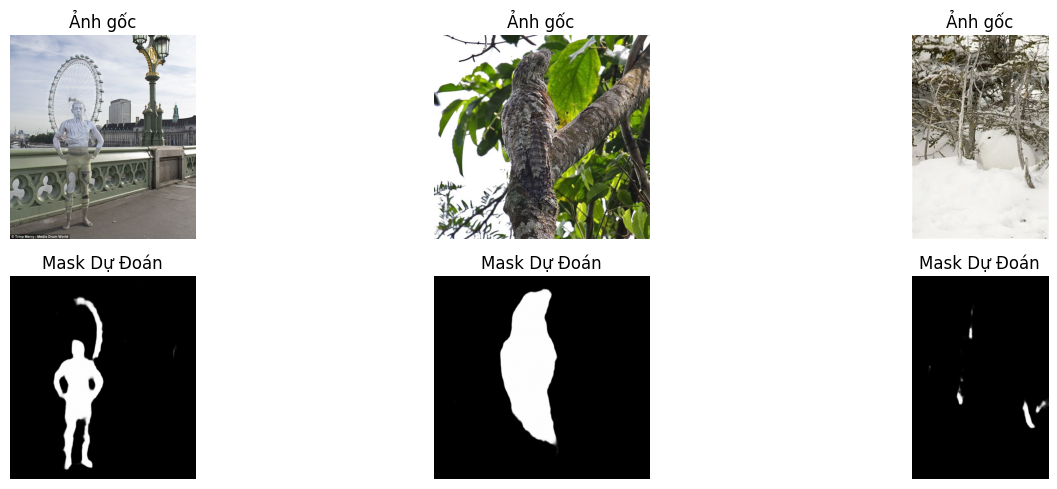

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob

# Đường dẫn ảnh gốc và ảnh dự đoán
img_dir = '/kaggle/working/dataset/val/images/'
pred_dir = '/kaggle/working/results/' # Thư mục lưu kết quả từ lệnh test.py

# Lấy thử 3 ảnh ngẫu nhiên
img_paths = glob.glob(os.path.join(img_dir, '*.*'))[:3]

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(img_paths):
    img_name = os.path.basename(img_path)
    base_name, _ = os.path.splitext(img_name)
    pred_path = os.path.join(pred_dir, f'{base_name}.png')

    # Vẽ ảnh gốc
    plt.subplot(2, 3, i + 1)
    plt.imshow(mpimg.imread(img_path))
    plt.title("Ảnh gốc")
    plt.axis('off')

    # Vẽ mask dự đoán (nếu có)
    if os.path.exists(pred_path):
        plt.subplot(2, 3, i + 4)
        plt.imshow(mpimg.imread(pred_path), cmap='gray')
        plt.title("Mask Dự Đoán")
        plt.axis('off')

plt.tight_layout()
plt.show()